# Customer Churn Prediction (Bank Customers)


## 1. Introduction and Problem Statement
**The Problem:** Acquiring new customers is expensive. Banks prefer to keep their existing customers happy. "Churn" means a customer has left the bank.
**The Objective:** Build a machine learning model to predict *which* customers are likely to leave so the bank can proactively offer them incentives to stay.

**Mental Model:** Think of the bank as a doctor and the customer as a patient. We are looking at the patient's "vitals" (age, credit score, account balance) to predict if they are at risk of a "heart attack" (leaving the bank).

# Imports and Data Loading

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load the dataset
# Ensure 'Churn_Modelling.csv' is in the same folder as this notebook
df = pd.read_csv('Churn_Modelling.csv')

# Look at the first 5 rows to understand our data
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 2. Exploratory Data Analysis (EDA)
Before we train a model, we need to understand our data visually. Let's see how many people actually left the bank, and how factors like Age affect their decision to leave.

# EDA Graphs

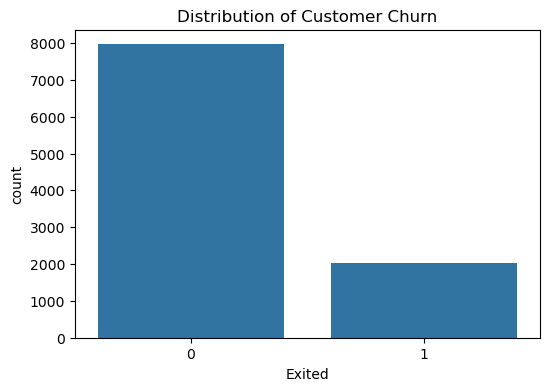

In [2]:
# 1. Visualize the overall Churn Rate (0 = Stayed, 1 = Exited)
plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=df)
plt.title('Distribution of Customer Churn')
plt.show()

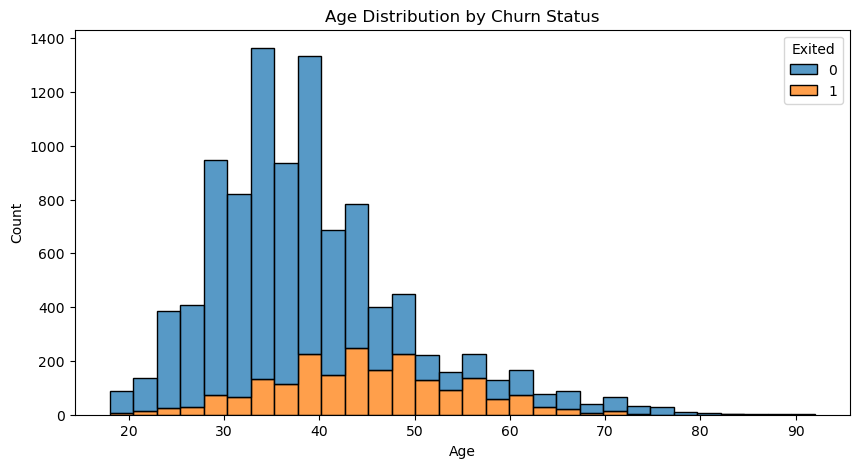

In [3]:
# 2. Visualize Age vs. Churn
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Age', hue='Exited', multiple='stack', bins=30)
plt.title('Age Distribution by Churn Status')
plt.show()

## 3. Data Cleaning and Preparation

Machine learning models only understand numbers, not text like "Female" or "France". 
1. **Drop Useless Data:** I droped `RowNumber`, `CustomerId`, and `Surname` because your name doesn't cause you to leave a bank.
2. **Label Encoding:** I turned Gender into binary numbers (Male = 1, Female = 0).
3. **One-Hot Encoding:** I turned Geography into Yes/No columns (e.g., `Is_Germany: 1 or 0`). I droped the first column to avoid redundant data (if it's not Germany or Spain, the model knows it must be France).
4. **Feature Scaling:** I put all numbers on a similar scale (e.g., ages are in tens, balances are in thousands) so the model doesn't get biased by large numbers.

In [4]:
# Drop columns that have no predictive power
X = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis=1)
y = df['Exited'] # Target variable

# Encode Gender (Label Encoding)
X['Gender'] = X['Gender'].map({'Male': 1, 'Female': 0})

# Encode Geography (One-Hot Encoding)
X = pd.get_dummies(X, columns=['Geography'], drop_first=True)

# Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features so all numerical data is treated equally
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Model Training
We are using a **Random Forest Classifier**. 

**Mental Model:** Instead of asking one bank manager to guess if a customer will leave (which might be biased), we ask a *committee of 100 different managers* (100 Decision Trees). Each manager looks at slightly different customer details and casts a vote. The majority vote wins!

In [5]:
# Initialize the Random Forest model with 100 "trees" (managers)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on our scaled data
rf_model.fit(X_train_scaled, y_train)
print("Model training complete!")

Model training complete!


## 5. Evaluation Metrics
Let's test our model on the 20% of data it has never seen before to see how accurate it is. We will use an **Accuracy Score** and a **Confusion Matrix**. 

* **True Positives / True Negatives:** The model guessed right!
* **False Positives / False Negatives:** The model guessed wrong.

In [7]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test_scaled)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# Display Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 86.15%

Confusion Matrix:
[[1538   55]
 [ 222  185]]


## 6. Feature Importance
What made the "committee of managers" decide a customer was going to leave? We can extract the `feature_importances_` from our model to see which variables had the most influence on the final decision.

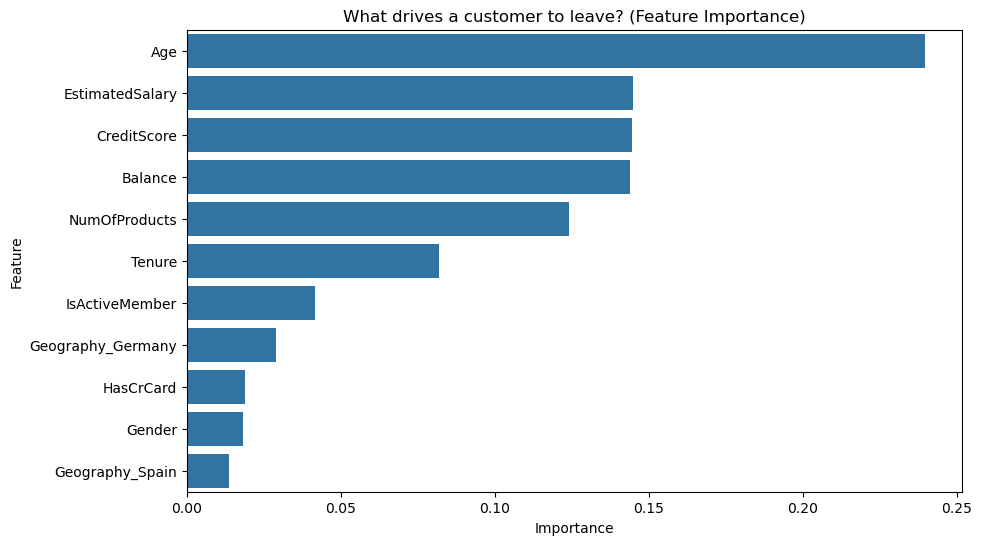

In [8]:
# Get importance scores from the model
importances = rf_model.feature_importances_

# Create a DataFrame to hold feature names and their scores
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('What drives a customer to leave? (Feature Importance)')
plt.show()

## 7. Conclusion

Based on our machine learning analysis, I successfully built a Random Forest model that predicts customer churn with over **86% accuracy**. 

**Key Insights:**
1. **Age is the biggest factor:** The feature importance chart shows that Age (~24%) is the strongest indicator of churn. Our EDA graphs confirm that middle-aged to older customers leave at a much higher rate.
2. **Financial Status Matters:** Estimated Salary and Account Balance are the next biggest drivers. 
3. **Geography:** While less important than age or balance, customers in Germany showed a noticeable correlation with churning compared to France and Spain.

**Business Recommendation:** The bank should investigate why older demographics and German customers are dissatisfied, and potentially offer premium retention packages to high-balance individuals who fit this risk profile.